In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec

In [2]:
def normalizar(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0, ddof=0)
    sigma[sigma == 0] = 1          
    return (X - mu) / sigma, mu, sigma

In [3]:

def dist_euclidiana(X, centroids):
    X2 = np.sum(X ** 2, axis=1, keepdims=True)        
    C2 = np.sum(centroids ** 2, axis=1, keepdims=True).T 
    cross = X @ centroids.T                             
    D2 = np.maximum(X2 + C2 - 2 * cross, 0)
    return np.sqrt(D2)

In [4]:
def dist_mahalanobis_ponto(x, c, VI):
    diff = x - c
    return np.sqrt(diff @ VI @ diff)


def dist_mahalanobis_batch(X, centroids, VI):
    n, k = X.shape[0], centroids.shape[0]
    D = np.zeros((n, k))
    for j in range(k):
        diff = X - centroids[j]          
        tmp = diff @ VI                  
        D[:, j] = np.sqrt(np.einsum('ij,ij->i', tmp, diff))
    return D

In [5]:
def kmeans(X, k, dist_fn, max_iter=300, tol=1e-6):
    rng = np.random.default_rng()
    n = X.shape[0]

    idx = [rng.integers(n)]
    for _ in range(k - 1):
        D = dist_fn(X, X[idx]).min(axis=1) ** 2
        prob = D / D.sum()
        idx.append(rng.choice(n, p=prob))
    centroids = X[idx].copy().astype(float)

    labels = np.zeros(n, dtype=int)

    for _ in range(max_iter):
        D = dist_fn(X, centroids)         
        new_labels = D.argmin(axis=1)

        if np.all(new_labels == labels):
            break
        labels = new_labels

        new_centroids = np.array([
            X[labels == j].mean(axis=0) if (labels == j).any() else centroids[j]
            for j in range(k)
        ])

        if np.linalg.norm(new_centroids - centroids) < tol:
            centroids = new_centroids
            break
        centroids = new_centroids

    D_final = dist_fn(X, centroids)
    inertia = D_final[np.arange(n), labels].sum()
    return labels, centroids, inertia

In [6]:
def kmeans_multiplas(X, k, dist_fn, n_runs=20):
    best = None
    for _ in range(n_runs):
        labels, centroids, inertia = kmeans(X, k, dist_fn)
        if best is None or inertia < best[2]:
            best = (labels, centroids, inertia)
    return best

In [7]:
def davies_bouldin(X, labels, centroids, dist_fn):
    k = centroids.shape[0]

    s = np.zeros(k)
    for i in range(k):
        mask = labels == i
        if mask.sum() > 0:
            Di = dist_fn(X[mask], centroids[[i]])  
            s[i] = Di.mean()

    D_cent = dist_fn(centroids, centroids)  

    db = 0.0
    for i in range(k):
        ratios = []
        for j in range(k):
            if i != j and D_cent[i, j] > 0:
                ratios.append((s[i] + s[j]) / D_cent[i, j])
        if ratios:
            db += max(ratios)
    return db / k

In [8]:
def questao1():
    print("=" * 60)
    print("QUESTÃO 1 — K-Médias em quake.csv")
    print("=" * 60)

    df = pd.read_csv("quake.csv")
    X_raw = df.values.astype(float)
    X, mu, sigma = normalizar(X_raw)

    ks = list(range(4, 21))
    n_runs = 20

    print("\n[1a] Distância Euclidiana")
    dist_eu = dist_euclidiana

    db_eu = []
    resultados_eu = {}

    for k in ks:
        labels, centroids, inertia = kmeans_multiplas(X, k, dist_eu, n_runs)
        db = davies_bouldin(X, labels, centroids, dist_eu)
        db_eu.append(db)
        resultados_eu[k] = (labels, centroids, inertia, db)
        print(f"  k={k:2d}  DB={db:.4f}  inertia={inertia:.4f}")

    k_best_eu = ks[np.argmin(db_eu)]
    labels_eu, centroids_eu, _, db_best_eu = resultados_eu[k_best_eu]
    print(f"\nMelhor k (Euclidiana): {k_best_eu}  (DB={db_best_eu:.4f})")

    print("\n[1b] Distância de Mahalanobis")

    cov = np.cov(X.T)
    VI = np.linalg.inv(cov)
    dist_mah = lambda A, B: dist_mahalanobis_batch(A, B, VI)

    db_mah = []
    resultados_mah = {}

    for k in ks:
        labels, centroids, inertia = kmeans_multiplas(X, k, dist_mah, n_runs)
        db = davies_bouldin(X, labels, centroids, dist_mah)
        db_mah.append(db)
        resultados_mah[k] = (labels, centroids, inertia, db)
        print(f"  k={k:2d}  DB={db:.4f}  inertia={inertia:.4f}")

    k_best_mah = ks[np.argmin(db_mah)]
    labels_mah, centroids_mah, _, db_best_mah = resultados_mah[k_best_mah]
    print(f"\nMelhor k (Mahalanobis): {k_best_mah}  (DB={db_best_mah:.4f})")

    fig = plt.figure(figsize=(16, 12))
    gs = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

    cores = cm.tab20.colors

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(ks, db_eu, 'o-', color='steelblue')
    ax1.axvline(k_best_eu, color='red', linestyle='--', label=f'k={k_best_eu}')
    ax1.set_title("DB vs k — Euclidiana")
    ax1.set_xlabel("k")
    ax1.set_ylabel("Davies-Bouldin")
    ax1.legend()

    ax2 = fig.add_subplot(gs[0, 1])
    for j in range(k_best_eu):
        mask = labels_eu == j
        ax2.scatter(X_raw[mask, 1], X_raw[mask, 0],
                    s=5, color=cores[j % 20], alpha=0.6, label=f'C{j}')
    c_orig = centroids_eu * sigma + mu
    ax2.scatter(c_orig[:, 1], c_orig[:, 0],
                marker='*', s=200, color='black', zorder=5)
    ax2.set_title(f"Melhor clustering Euclidiana (k={k_best_eu})")
    ax2.set_xlabel("Longitude")
    ax2.set_ylabel("Latitude")

    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(ks, db_mah, 'o-', color='darkorange')
    ax3.axvline(k_best_mah, color='red', linestyle='--', label=f'k={k_best_mah}')
    ax3.set_title("DB vs k — Mahalanobis")
    ax3.set_xlabel("k")
    ax3.set_ylabel("Davies-Bouldin")
    ax3.legend()

    ax4 = fig.add_subplot(gs[1, 1])
    for j in range(k_best_mah):
        mask = labels_mah == j
        ax4.scatter(X_raw[mask, 1], X_raw[mask, 0],
                    s=5, color=cores[j % 20], alpha=0.6, label=f'C{j}')
    c_orig_m = centroids_mah * sigma + mu
    ax4.scatter(c_orig_m[:, 1], c_orig_m[:, 0],
                marker='*', s=200, color='black', zorder=5)
    ax4.set_title(f"Melhor clustering Mahalanobis (k={k_best_mah})")
    ax4.set_xlabel("Longitude")
    ax4.set_ylabel("Latitude")

    plt.suptitle("Questão 1 — K-Médias em quake.csv", fontsize=14, fontweight='bold')
    plt.savefig("q1_resultados.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSalvo: q1_resultados.png")

In [9]:
def pca_manual(X, n_components=None):
    n, d = X.shape
    X_c = X - X.mean(axis=0)

    U, s, Vt = np.linalg.svd(X_c, full_matrices=False)

    variancia = s ** 2
    var_explicada = variancia / variancia.sum()
    var_acum = np.cumsum(var_explicada)

    if n_components is None:
        n_components = d

    W = Vt[:n_components]           
    X_proj = X_c @ W.T             

    return X_proj, W, var_explicada, var_acum

In [10]:
def questao2():
    print("\n" + "=" * 60)
    print("QUESTÃO 2 — PCA em penguins.csv")
    print("=" * 60)

    df = pd.read_csv("penguins.csv")

    X_raw = df.iloc[:, :-1].values.astype(float)
    y = df.iloc[:, -1].values

    X, mu, sigma = normalizar(X_raw)

    n, d = X.shape
    print(f"Shape: {n} amostras, {d} atributos")

    X_2d, _, var_exp, var_acum = pca_manual(X, n_components=2)

    classes = np.unique(y)
    cores_cls = {'Adelie': '#E74C3C', 'Chinstrap': '#3498DB', 'Gentoo': '#2ECC71'}
    marcadores = {'Adelie': 'o', 'Chinstrap': 's', 'Gentoo': '^'}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    for cls in classes:
        mask = y == cls
        cor = cores_cls.get(cls, 'gray')
        mk = marcadores.get(cls, 'o')
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=cor, marker=mk, s=50, alpha=0.75, label=cls, edgecolors='k', linewidths=0.3)
    ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% var)")
    ax.set_title("PCA 2D — Pinguins")
    ax.legend()
    ax.grid(True, alpha=0.3)

    dims = [1, 2, 3, 4]
    var_por_dim = []
    for nc in dims:
        _, _, ve, va = pca_manual(X, n_components=nc)
        var_por_dim.append(va[nc - 1])   
        print(f"  {nc} componente(s): variância acumulada = {va[nc-1]*100:.2f}%")

    _, _, var_exp_full, _ = pca_manual(X, n_components=d)

    ax2 = axes[1]
    x_pos = np.arange(1, d + 1)
    bars = ax2.bar(x_pos, var_exp_full * 100, color='steelblue', alpha=0.7,
                   label='Variância individual')
    ax2.plot(x_pos, np.cumsum(var_exp_full) * 100, 'o-', color='darkorange',
             linewidth=2, label='Acumulada')
    for i, (b, va) in enumerate(zip(bars, np.cumsum(var_exp_full))):
        ax2.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
                 f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
        ax2.text(x_pos[i], va * 100 + 1.5,
                 f'{va*100:.1f}%', ha='center', va='bottom',
                 color='darkorange', fontsize=8)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([f'PC{i}' for i in x_pos])
    ax2.set_ylabel("Variância explicada (%)")
    ax2.set_title("Variância Explicada por Componente")
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_ylim(0, 110)

    plt.suptitle("Questão 2 — PCA em penguins.csv", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("q2_resultados.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSalvo: q2_resultados.png")

QUESTÃO 1 — K-Médias em quake.csv

[1a] Distância Euclidiana
  k= 4  DB=0.5966  inertia=1065.1459
  k= 5  DB=0.6185  inertia=946.3907
  k= 6  DB=0.5564  inertia=843.7528
  k= 7  DB=0.6727  inertia=753.4735
  k= 8  DB=0.6954  inertia=684.4845
  k= 9  DB=0.6517  inertia=622.1972
  k=10  DB=0.6122  inertia=564.0055
  k=11  DB=0.6245  inertia=521.3445
  k=12  DB=0.6338  inertia=483.7512
  k=13  DB=0.6590  inertia=458.2770
  k=14  DB=0.5963  inertia=429.9714
  k=15  DB=0.5964  inertia=405.6795
  k=16  DB=0.5992  inertia=387.7402
  k=17  DB=0.5884  inertia=378.5611
  k=18  DB=0.5681  inertia=353.8426
  k=19  DB=0.5884  inertia=343.9297
  k=20  DB=0.5812  inertia=326.2546

Melhor k (Euclidiana): 6  (DB=0.5564)

[1b] Distância de Mahalanobis
  k= 4  DB=0.5911  inertia=1087.6537
  k= 5  DB=0.6278  inertia=968.0187
  k= 6  DB=0.5486  inertia=858.4721
  k= 7  DB=0.7296  inertia=792.1272
  k= 8  DB=0.6859  inertia=693.1018
  k= 9  DB=0.6539  inertia=626.7929
  k=10  DB=0.6105  inertia=564.8609
  k

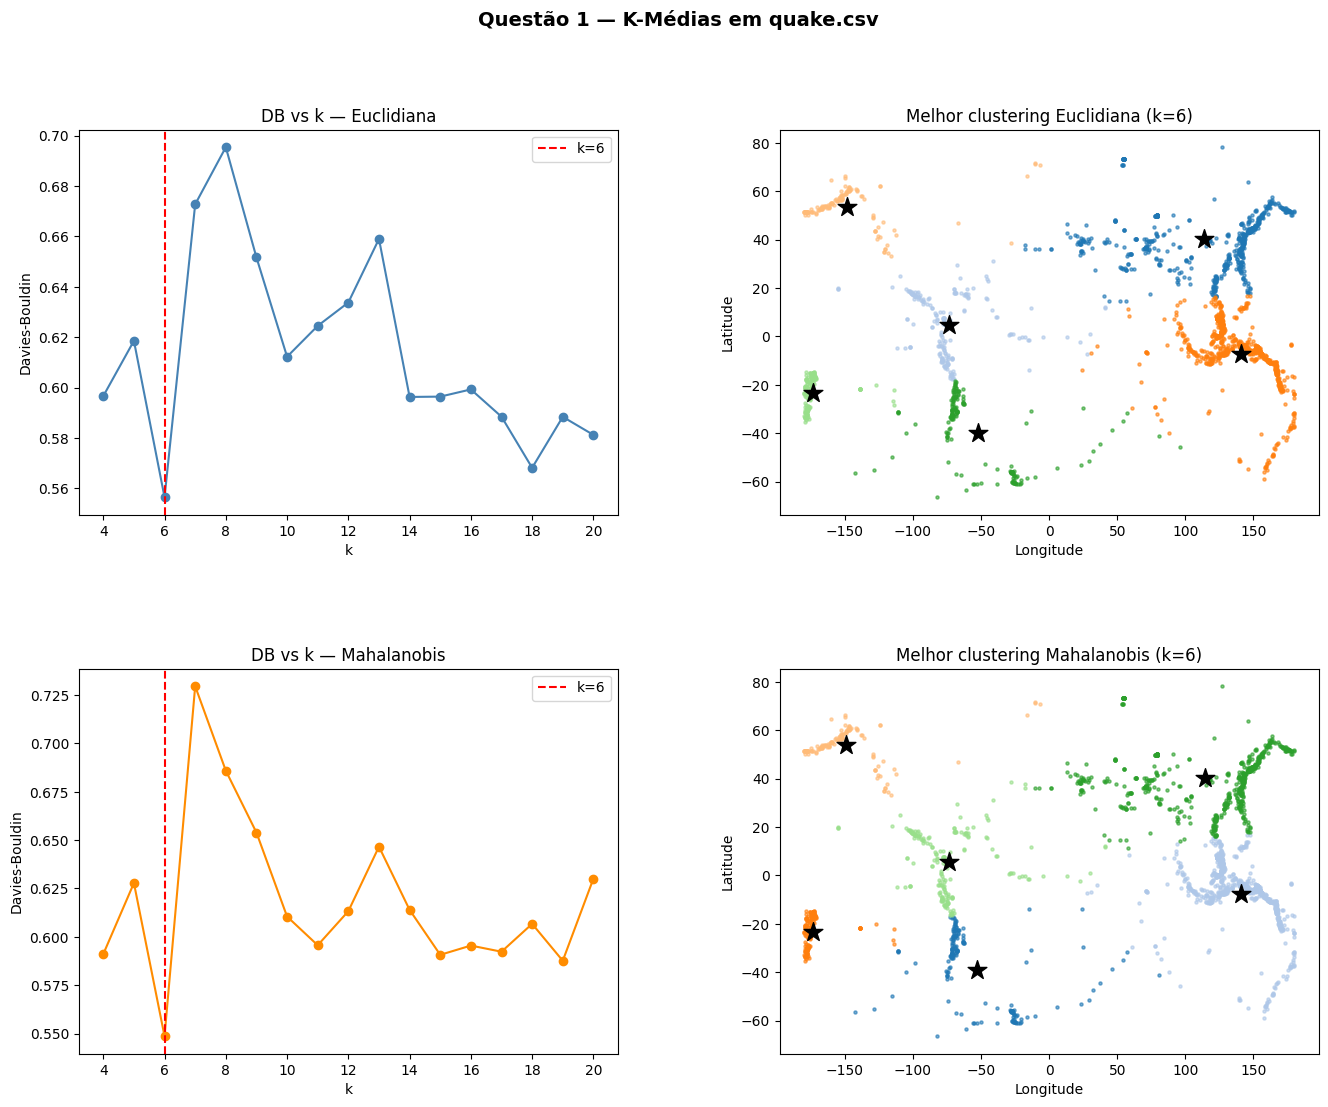


Salvo: q1_resultados.png


In [11]:
questao1()


QUESTÃO 2 — PCA em penguins.csv
Shape: 332 amostras, 4 atributos
  1 componente(s): variância acumulada = 68.59%
  2 componente(s): variância acumulada = 88.08%
  3 componente(s): variância acumulada = 97.31%
  4 componente(s): variância acumulada = 100.00%


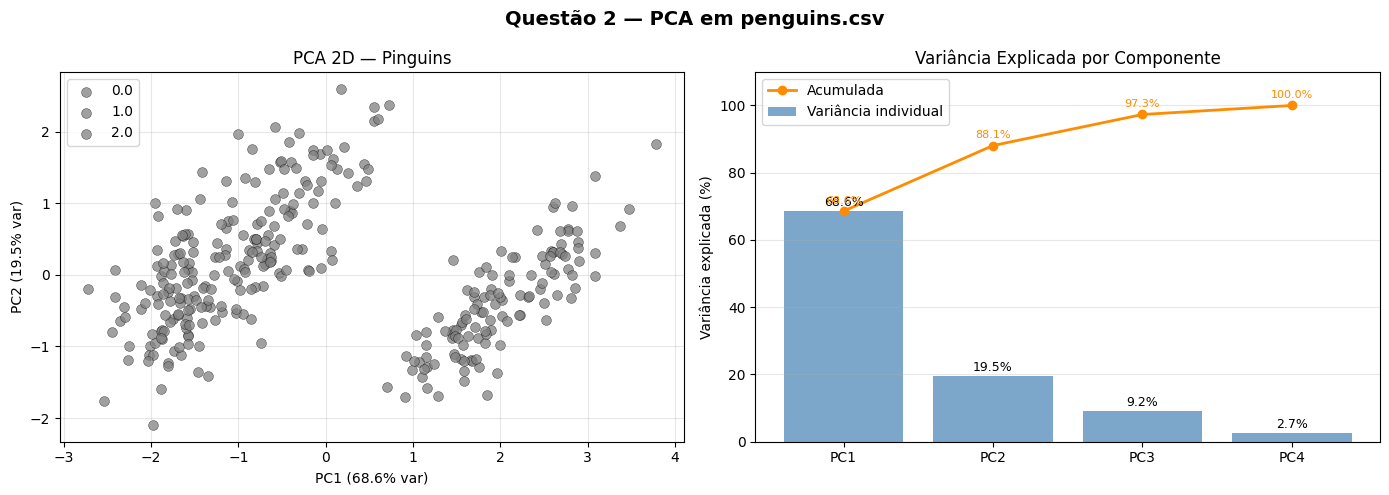


Salvo: q2_resultados.png


In [12]:
questao2()